# Building ChatBot with Multiple Tools

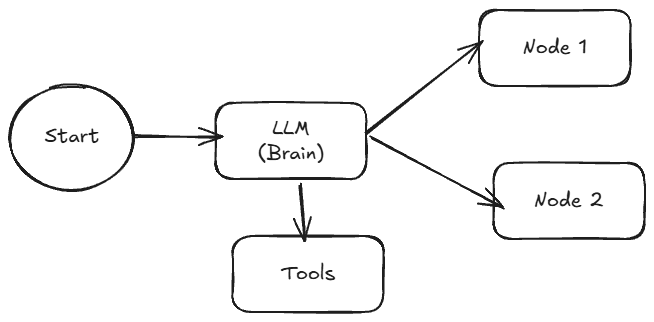

Integrate with arxiv, wikipedia search, tavily search engine

In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage
from typing_extensions import TypedDict
from typing import Annotated
from langchain_core.messages import AIMessage,HumanMessage
from IPython.display import display, Image
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langchain_ollama import ChatOllama

C:\Users\Hanif\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
from dotenv import load_dotenv
load_dotenv()
tavily_api_key = os.getenv("TAVILY_API_KEY")

In [3]:
from langchain_groq import ChatGroq
GROQ_API_KEY= os.getenv('GROQ_API_KEY')
llm = ChatOllama(model='llama3.1:8b')
llm.invoke('Hi Llama  what is your model name?')

AIMessage(content='My model name is "LLaMA" (Large Language Model Application). I\'m a type of artificial intelligence designed to understand and generate human-like text. My training data is based on a massive corpus of text, which enables me to respond to a wide range of questions and topics!', additional_kwargs={}, response_metadata={'model': 'llama3.1:8b', 'created_at': '2025-08-03T07:25:07.0279212Z', 'done': True, 'done_reason': 'stop', 'total_duration': 20799739100, 'load_duration': 17260789100, 'prompt_eval_count': 20, 'prompt_eval_duration': 648011800, 'eval_count': 58, 'eval_duration': 2874037800, 'model_name': 'llama3.1:8b'}, id='run--d4b60d26-6cf6-49b3-9a63-59ccf8fa73aa-0', usage_metadata={'input_tokens': 20, 'output_tokens': 58, 'total_tokens': 78})

In [4]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

In [5]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=1000)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
arxiv.invoke('What is the latest research on LLMs?')

'Published: 2024-12-18\nTitle: LLMSA: A Compositional Neuro-Symbolic Approach to Compilation-free and Customizable Static Analysis\nAuthors: Chengpeng Wang, Yifei Gao, Wuqi Zhang, Xuwei Liu, Qingkai Shi, Xiangyu Zhang\nSummary: Static analysis is essential for program optimization, bug detection, and\ndebugging, but its reliance on compilation and limited customization hampers\npractical use. Advances in LLMs enable a new paradigm of compilation-free,\ncustomizable analysis via prompting. LLMs excel in interpreting program\nsemantics on small code snippets and allow users to define analysis tasks in\nnatural language with few-shot examples. However, misalignment with program\nsemantics can cause hallucinations, especially in sophisticated semantic\nanalysis upon lengthy code snippets.\n  We propose LLMSA, a compositional neuro-symbolic approach for\ncompilation-free, customizable static analysis with reduced hallucinations.\nSpecifically, we propose an analysis policy language to suppo

In [6]:
api_wrapper_wikipedia = WikipediaAPIWrapper(top_k_results=2,doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wikipedia)
wiki.name

'wikipedia'

In [7]:
wiki.invoke('Large Language Models')

'Page: Large language model\nSummary: A large language model (LLM) is a language model trained with self-supervised machine learning on a vast amount of text, designed for natural language processing tasks, especially language generation.\nThe largest and most capable LLMs are generative pretrained transformers (GPTs), which are largely used in generative chatbots such as ChatGPT, Gemini or Claude. LLMs can be fine-tuned for specific tasks or guided by prompt engineering. These models acquire predi'

In [8]:
# add Tavily Search Engine
from langchain_community.tools import TavilySearchResults
tavily_search_engine = TavilySearchResults(tavily_api_key=tavily_api_key,top_k=2)

In [9]:
tavily_search_engine.invoke('What is the lastest news AI LLM?')

[{'title': 'Latest AI Breakthroughs and News: May, June, July 2025',
  'url': 'https://www.crescendo.ai/news/latest-ai-news-and-updates',
  'content': '### Crescendo and Amazon Deliver Breakthrough in AI Voice Support\n\nDate: July 17, 2025\n\nSummary: Crescendo.ai has partnered with Amazon to integrate Nova Sonic, a high-speed LLM model, into its voice AI platform. The upgrade drastically reduces latency and improves natural fluency across 50+ languages. Crescendo says it now offers the fastest, most human-like AI voice support on the market. The launch redefines real-time multilingual voice assistance at scale.\n\nSource:Yahoo Finance\n\n\u200d [...] ### WormGPT Returns With Dangerous New AI Variants\n\nDate: June 20, 2025\n\nSummary: Cybersecurity researchers have uncovered new malicious AI variants based on WormGPT, including strains built on Grok and Mixtral models. These tools are being used to automate phishing, malware creation, and other cyberattacks with advanced precision. T

In [10]:
# combine all tools
tools = [arxiv,wiki,tavily_search_engine]

In [11]:
llm_with_tools = llm.bind_tools(tools)

In [12]:
llm_with_tools.invoke([HumanMessage(content="What is the recent AI research?")])

AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.1:8b', 'created_at': '2025-08-03T07:25:16.559247Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1709235800, 'load_duration': 35196100, 'prompt_eval_count': 369, 'prompt_eval_duration': 553775900, 'eval_count': 23, 'eval_duration': 1118492400, 'model_name': 'llama3.1:8b'}, id='run--3848c9a0-dc37-42ef-a40b-d232a99741dc-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'recent AI research'}, 'id': '8bb1998c-a136-4fe8-9141-aa2159b6b53a', 'type': 'tool_call'}], usage_metadata={'input_tokens': 369, 'output_tokens': 23, 'total_tokens': 392})

In [13]:
llm_with_tools.invoke([HumanMessage(content="What is the recent AI research?")]).tool_calls

[{'name': 'arxiv',
  'args': {'query': 'recent AI research'},
  'id': '2bf98aef-ba71-4c81-aafe-fb712ab3d29b',
  'type': 'tool_call'}]

Compile Entire ChatBot Graph

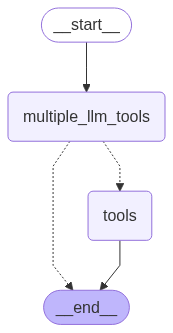

In [14]:
# Add tools condition to integrate tools with LLM
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage
from typing_extensions import TypedDict
from typing import Annotated

class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

### create tools node functionality
def llm_tools(state:State):
    return {'messages':[llm_with_tools.invoke(state['messages'])]}


# Initial Graph and Node
tool_graph = StateGraph(State)
tool_graph.add_node('multiple_llm_tools',llm_tools)
tool_graph.add_node('tools',ToolNode(tools))


# Add Conditional Edge
tool_graph.add_edge(START, 'multiple_llm_tools')
tool_graph.add_conditional_edges('multiple_llm_tools',tools_condition)
tool_graph.add_edge('tools', END)

compiled_tool_graph = tool_graph.compile()
display(Image(compiled_tool_graph.get_graph().draw_mermaid_png()))

In [15]:
response = compiled_tool_graph.invoke({'messages':'who is pep guardiola?'})

for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

who is pep guardiola?
================================== Ai Message ==================================
Tool Calls:
  wikipedia (5750f7b4-4ebe-4449-915d-81b738ba2a89)
 Call ID: 5750f7b4-4ebe-4449-915d-81b738ba2a89
  Args:
    query: Pep Guardiola
================================= Tool Message =================================
Name: wikipedia

Page: Pep Guardiola
Summary: Josep "Pep" Guardiola Sala (Catalan pronunciation: [ˈpɛb ɡwəɾðiˈɔlə]; born 18 January 1971) is a Spanish professional football manager and former player who has been the manager of Premier League club Manchester City since 2016. Guardiola is one of two managers in history to win the continental treble twice and he holds the record for the most consecutive league games won in La Liga, Bundesliga, and the Premier League. He is considered to be one of the greatest manag


In [16]:
response = compiled_tool_graph.invoke({'messages':'what is AI utilization prediction in 2025 based on BCG, Deloitte, and McKinsey reports?'})

for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

what is AI utilization prediction in 2025 based on BCG, Deloitte, and McKinsey reports?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (1a106b57-066a-4741-9bc1-4d07128dd998)
 Call ID: 1a106b57-066a-4741-9bc1-4d07128dd998
  Args:
    query: AI utilization prediction 2025 according to BCG Deloitte and McKinsey
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "BCG's AI at Work 2025 report: Four takeaways for HR leaders", "url": "https://www.unleash.ai/artificial-intelligence/bcgs-ai-at-work-2025-report-four-takeaways-for-hr-leaders/", "content": "Regular use – defined as people that use AI several times a week or daily – rose 14% among managers to 78% in 2025 (64% in 2023, 46% in 2018).\n\nDespite a stall in use, confidence among frontline workers has grown t

In [17]:
response = compiled_tool_graph.invoke({'messages':'what is AI top paper in ArXiv in June 2025?'})

for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

what is AI top paper in ArXiv in June 2025?
================================== Ai Message ==================================
Tool Calls:
  arxiv (3ec84cfb-da61-419b-8e5b-f937c3789b26)
 Call ID: 3ec84cfb-da61-419b-8e5b-f937c3789b26
  Args:
    query: AI top paper ArXiv June 2025
================================= Tool Message =================================
Name: arxiv

Published: 2023-12-09
Title: NLLG Quarterly arXiv Report 09/23: What are the most influential current AI Papers?
Authors: Ran Zhang, Aida Kostikova, Christoph Leiter, Jonas Belouadi, Daniil Larionov, Yanran Chen, Vivian Fresen, Steffen Eger
Summary: Artificial Intelligence (AI) has witnessed rapid growth, especially in the
subfields Natural Language Processing (NLP), Machine Learning (ML) and Computer
Vision (CV). Keeping pace with this rapid progress poses a considerable
challenge for researchers and professionals in the field. In this ar

# React Architecture

ReACT (Reason + Action) architecture:
1. Act : Let the model call specific tools
2. Observer : Pass the output back to the model
3. Reason : Let the model reason about the tool output decide what to do next (example : call another tool or just response directly)

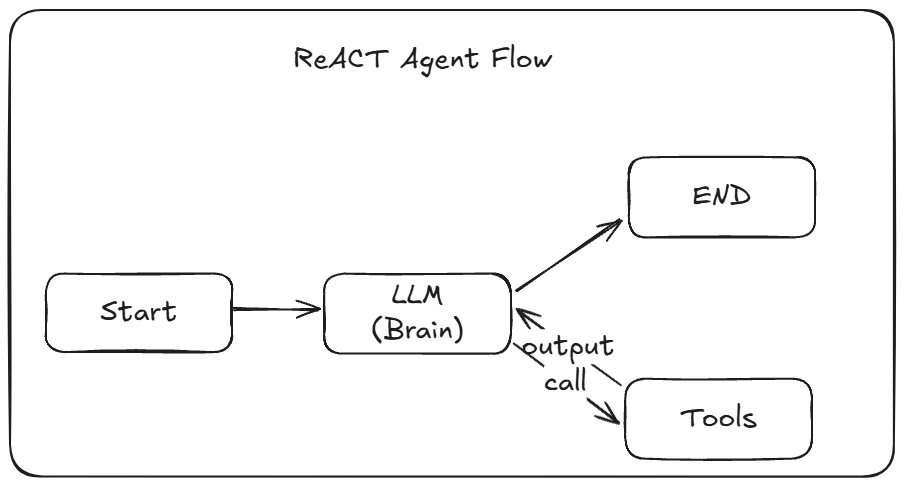

 call multiple tools

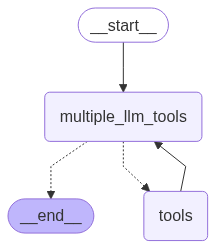

In [18]:
# Add tools condition to integrate tools with LLM
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage
from typing_extensions import TypedDict
from typing import Annotated

class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

### create tools node functionality
def llm_tools(state:State):
    return {'messages':[llm_with_tools.invoke(state['messages'])]}


# Initial Graph and Node
tool_graph = StateGraph(State)
tool_graph.add_node('multiple_llm_tools',llm_tools)
tool_graph.add_node('tools',ToolNode(tools))


# Add Conditional Edge
tool_graph.add_edge(START, 'multiple_llm_tools')
tool_graph.add_conditional_edges('multiple_llm_tools',tools_condition)
tool_graph.add_edge('tools', 'multiple_llm_tools')

compiled_tool_graph = tool_graph.compile()
display(Image(compiled_tool_graph.get_graph().draw_mermaid_png()))

In [19]:
response = compiled_tool_graph.invoke({'messages':'what is latest AI news in June 2025? then provide me too paper for this 1706.03762. Thank you'})

for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

what is latest AI news in June 2025? then provide me too paper for this 1706.03762. Thank you
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (704b49c2-30cb-4f0b-b150-6370258e075f)
 Call ID: 704b49c2-30cb-4f0b-b150-6370258e075f
  Args:
    query: latest AI news June 2025
  arxiv (4a2fbaca-e6c5-4c3a-a723-532364071767)
 Call ID: 4a2fbaca-e6c5-4c3a-a723-532364071767
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "The latest AI news we announced in June - Google Blog", "url": "https://blog.google/technology/ai/google-ai-updates-june-2025/", "content": "# The latest AI news we announced in June\n\nJul 02, 2025\n\nHere’s a recap of some of our biggest AI updates from June, including more ways to search with AI Mode, a new way to sh

# Add Memory to Your Agent

## Memory Saver

LangGraph automatically  save the graph state every step. Have built-in presistance layer to give the memory. Allowing LangGraph to pick up from last state update. You can utlize memory key-value store in Graph state. So we need to compile the graph with the checkpointer, and our graph has memory

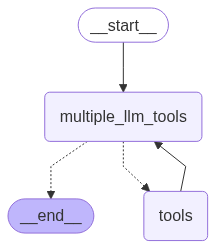

In [20]:
from langgraph.checkpoint.memory import MemorySaver

# Add tools condition to integrate tools with LLM
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage
from typing_extensions import TypedDict
from typing import Annotated

class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

### create tools node functionality
def llm_tools(state:State):
    return {'messages':[llm_with_tools.invoke(state['messages'])]}


# Initial Graph and Node
tool_graph = StateGraph(State)
tool_graph.add_node('multiple_llm_tools',llm_tools)
tool_graph.add_node('tools',ToolNode(tools))


# Add Conditional Edge
tool_graph.add_edge(START, 'multiple_llm_tools')
tool_graph.add_conditional_edges('multiple_llm_tools',tools_condition)
tool_graph.add_edge('tools', 'multiple_llm_tools')

memory_type = MemorySaver()
compiled_tool_graph_memory = tool_graph.compile(checkpointer=memory_type)
display(Image(compiled_tool_graph.get_graph().draw_mermaid_png()))

In [21]:
config = {"configurable":{"thread_id":"1"}}

In [22]:
response = compiled_tool_graph_memory.invoke({'messages':'what is latest AI news in June 2025? then provide me too paper for this 1706.03762. Thank you'},config=config)
for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

what is latest AI news in June 2025? then provide me too paper for this 1706.03762. Thank you
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (f7159f98-88ed-4877-ac3b-71f95b315cfb)
 Call ID: f7159f98-88ed-4877-ac3b-71f95b315cfb
  Args:
    query: latest AI news June 2025
  arxiv (67435f49-7bf9-4393-bac7-49ba4022b06c)
 Call ID: 67435f49-7bf9-4393-bac7-49ba4022b06c
  Args:
    query: paper ID: 1706.03762
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "The latest AI news we announced in June - Google Blog", "url": "https://blog.google/technology/ai/google-ai-updates-june-2025/", "content": "# The latest AI news we announced in June\n\nJul 02, 2025\n\nHere’s a recap of some of our biggest AI updates from June, including more ways to search with AI Mode, a new

In [23]:
response = compiled_tool_graph_memory.invoke({'messages':'please give me link your AI news before'},config=config)
for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

what is latest AI news in June 2025? then provide me too paper for this 1706.03762. Thank you
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (f7159f98-88ed-4877-ac3b-71f95b315cfb)
 Call ID: f7159f98-88ed-4877-ac3b-71f95b315cfb
  Args:
    query: latest AI news June 2025
  arxiv (67435f49-7bf9-4393-bac7-49ba4022b06c)
 Call ID: 67435f49-7bf9-4393-bac7-49ba4022b06c
  Args:
    query: paper ID: 1706.03762
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "The latest AI news we announced in June - Google Blog", "url": "https://blog.google/technology/ai/google-ai-updates-june-2025/", "content": "# The latest AI news we announced in June\n\nJul 02, 2025\n\nHere’s a recap of some of our biggest AI updates from June, including more ways to search with AI Mode, a new

In [24]:
print(response.get('messages', []))

[HumanMessage(content='what is latest AI news in June 2025? then provide me too paper for this 1706.03762. Thank you', additional_kwargs={}, response_metadata={}, id='4cf37e29-a91a-487a-ac42-79b67ef0eb62'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.1:8b', 'created_at': '2025-08-03T07:25:54.9828493Z', 'done': True, 'done_reason': 'stop', 'total_duration': 3126775000, 'load_duration': 35217600, 'prompt_eval_count': 389, 'prompt_eval_duration': 394262000, 'eval_count': 52, 'eval_duration': 2695950300, 'model_name': 'llama3.1:8b'}, id='run--42d23ad6-a095-4279-badf-1aa11fb80ae6-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'latest AI news June 2025'}, 'id': 'f7159f98-88ed-4877-ac3b-71f95b315cfb', 'type': 'tool_call'}, {'name': 'arxiv', 'args': {'query': 'paper ID: 1706.03762'}, 'id': '67435f49-7bf9-4393-bac7-49ba4022b06c', 'type': 'tool_call'}], usage_metadata={'input_tokens': 389, 'output_tokens': 52, 'total_tokens': 441}), T

# Langchain Stream and Astream

sync and async methods for back results

In [25]:
llm = ChatOllama(model='llama3.1:8b')
llm.invoke('Hi Llama  what is your model name?')

AIMessage(content='My model name is "LLaMA" which stands for Large Language Model Application. I\'m an AI designed to understand and generate human-like text based on the input you provide.', additional_kwargs={}, response_metadata={'model': 'llama3.1:8b', 'created_at': '2025-08-03T07:31:12.1580665Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2567732700, 'load_duration': 42566700, 'prompt_eval_count': 20, 'prompt_eval_duration': 619447400, 'eval_count': 37, 'eval_duration': 1905358200, 'model_name': 'llama3.1:8b'}, id='run--ae7df12b-f6c4-4d7c-b314-17fe30688b1f-0', usage_metadata={'input_tokens': 20, 'output_tokens': 37, 'total_tokens': 57})

In [26]:
memory = MemorySaver()
def superbot(state: State):
    return {'messages': [llm.invoke(state['messages'])]}

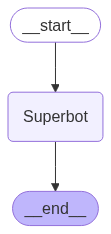

In [29]:
graph = StateGraph(State)
graph.add_node('Superbot', superbot)
graph.add_edge(START, 'Superbot')
graph.add_edge('Superbot',END)
graph_builder = graph.compile(checkpointer=memory)
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [33]:
config = {'configurable': {'thread_id': '1'}}
graph_builder.invoke({'messages':'Hi My name is Hanif. I am Data Engineer'},config)

{'messages': [HumanMessage(content='Hi My name is Hanif. I am Data Engineer', additional_kwargs={}, response_metadata={}, id='7d3c17bc-cd2c-4d93-a16f-a8e982e871ce'),
  AIMessage(content='Nice to meet you, Hanif! As a Data Engineer, what kind of projects or technologies are you currently working with? Are you enjoying your role in the data engineering space?', additional_kwargs={}, response_metadata={'model': 'llama3.1:8b', 'created_at': '2025-08-03T07:41:03.1270739Z', 'done': True, 'done_reason': 'stop', 'total_duration': 9583170600, 'load_duration': 6922046400, 'prompt_eval_count': 21, 'prompt_eval_duration': 638789200, 'eval_count': 37, 'eval_duration': 2021695600, 'model_name': 'llama3.1:8b'}, id='run--e3968a72-c78e-4aed-9ceb-397f48d86296-0', usage_metadata={'input_tokens': 21, 'output_tokens': 37, 'total_tokens': 58})]}

### Streaming

- updates : latest values of state

- values : entire values of state

In [ ]:
config = {'configurable': {'thread_id': '2'}}
for chunk in graph_builder.stream({'messages':'Hi My name is Hanif. I am Data Engineer'},config,stream_mode='updates'):
    print(chunk)


{'Superbot': {'messages': [AIMessage(content="Nice to meet you, Hanif! As a Data Engineer, you play a crucial role in helping organizations extract insights and value from their data. What specific areas of Data Engineering are you interested in or working on? Are you into big data processing with Hadoop/Spark, cloud-based data warehousing (e.g., AWS Redshift), real-time analytics, or perhaps machine learning engineering?\n\nLet's chat about your work!", additional_kwargs={}, response_metadata={'model': 'llama3.1:8b', 'created_at': '2025-08-03T07:43:35.007497Z', 'done': True, 'done_reason': 'stop', 'total_duration': 4920338400, 'load_duration': 22829100, 'prompt_eval_count': 21, 'prompt_eval_duration': 338287500, 'eval_count': 86, 'eval_duration': 4558691700, 'model_name': 'llama3.1:8b'}, id='run--a2c3a5bb-3bdb-4ffc-b55e-a44b972aab6b-0', usage_metadata={'input_tokens': 21, 'output_tokens': 86, 'total_tokens': 107})]}}


In [ ]:
for chunk in graph_builder.stream({'messages':'Hi My name is Hanif. I am Data Engineer'},config,stream_mode='values'):
    print(chunk)

{'messages': [HumanMessage(content='Hi My name is Hanif. I am Data Engineer', additional_kwargs={}, response_metadata={}, id='ea5301de-b5fb-453b-98f6-054fc0586665'), AIMessage(content="Nice to meet you, Hanif! As a Data Engineer, you play a crucial role in helping organizations extract insights and value from their data. What specific areas of Data Engineering are you interested in or working on? Are you into big data processing with Hadoop/Spark, cloud-based data warehousing (e.g., AWS Redshift), real-time analytics, or perhaps machine learning engineering?\n\nLet's chat about your work!", additional_kwargs={}, response_metadata={'model': 'llama3.1:8b', 'created_at': '2025-08-03T07:43:35.007497Z', 'done': True, 'done_reason': 'stop', 'total_duration': 4920338400, 'load_duration': 22829100, 'prompt_eval_count': 21, 'prompt_eval_duration': 338287500, 'eval_count': 86, 'eval_duration': 4558691700, 'model_name': 'llama3.1:8b'}, id='run--a2c3a5bb-3bdb-4ffc-b55e-a44b972aab6b-0', usage_metad

In [ ]:
for chunk in graph_builder.stream({'messages':'Hi My name is Hanif. I am Data Engineer. I use Azure and SAP as architecture'},config,stream_mode='values'):
    print(chunk)

{'messages': [HumanMessage(content='Hi My name is Hanif. I am Data Engineer', additional_kwargs={}, response_metadata={}, id='ea5301de-b5fb-453b-98f6-054fc0586665'), AIMessage(content="Nice to meet you, Hanif! As a Data Engineer, you play a crucial role in helping organizations extract insights and value from their data. What specific areas of Data Engineering are you interested in or working on? Are you into big data processing with Hadoop/Spark, cloud-based data warehousing (e.g., AWS Redshift), real-time analytics, or perhaps machine learning engineering?\n\nLet's chat about your work!", additional_kwargs={}, response_metadata={'model': 'llama3.1:8b', 'created_at': '2025-08-03T07:43:35.007497Z', 'done': True, 'done_reason': 'stop', 'total_duration': 4920338400, 'load_duration': 22829100, 'prompt_eval_count': 21, 'prompt_eval_duration': 338287500, 'eval_count': 86, 'eval_duration': 4558691700, 'model_name': 'llama3.1:8b'}, id='run--a2c3a5bb-3bdb-4ffc-b55e-a44b972aab6b-0', usage_metad

In [39]:
for chunk in graph_builder.stream({'messages':'Hi My name is Hanif. I am Data Engineer. I use Azure and SAP as architecture. I use Snowflake AS Data Warehouse and ADF as ETL Tools'},config,stream_mode='updates'):
    print(chunk)

{'Superbot': {'messages': [AIMessage(content="Nice to meet you, Hanif!\n\nIt sounds like you have a solid cloud-based data engineering architecture with Azure as the foundation. Using Snowflake as your data warehouse is a great choice, it's a powerful and flexible platform for storing and analyzing large datasets.\n\nAnd using Azure Data Factory (ADF) as your ETL tool makes sense, it's a robust and scalable platform for automating data integration processes.\n\nSo, here's what I've got from our conversation so far:\n\n* You're working on an architecture that combines Azure with SAP systems.\n* You use Snowflake as your primary data warehouse.\n* You use ADF (Azure Data Factory) for ETL/ELT processes.\n\nI'm curious to know more about your experience with these tools and how you're using them in your projects. Have you encountered any challenges or complexities while working on this architecture?\n\nAlso, are there any specific goals or objectives that you're trying to achieve with your

## Stream with astream methods

stream back results all of graph state

chat model call it is common to stream the token as generated

.astream_events_methods can help stream back event

each event have this information as dict:

- event
- name
- data
- metadata

In [40]:
config = {'configurable': {'thread_id': '3'}}
async for event in graph_builder.astream_events({'messages':'Hi My name is Hanif. I am Data Engineer. I use Azure and SAP as architecture. I use Snowflake AS Data Warehouse and ADF as ETL Tools. I want the new news to update optimize my ETL and integration process'},config):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hi My name is Hanif. I am Data Engineer. I use Azure and SAP as architecture. I use Snowflake AS Data Warehouse and ADF as ETL Tools. I want the new news to update optimize my ETL and integration process'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '9b630863-dc95-4507-8e37-9e0a028fa3ef', 'metadata': {'thread_id': '3'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Hanif. I am Data Engineer. I use Azure and SAP as architecture. I use Snowflake AS Data Warehouse and ADF as ETL Tools. I want the new news to update optimize my ETL and integration process', additional_kwargs={}, response_metadata={}, id='9d78ed3a-7fa9-442e-94c7-bb5ddffd9a4f')]}}, 'name': 'Superbot', 'tags': ['graph:step:1'], 'run_id': 'a6b16142-148c-411a-874e-7c60e940195b', 'metadata': {'thread_id': '3', 'langgraph_step': 1, 'langgraph_node': 'Superbot', 'langgraph_triggers': ('branch:to:Superbot